# Traffic Light Classification using VGG16 Transfer Learning

This notebook is designed for the red/green two-light traffic-light coursework. It uses **VGG16** instead of ResNet50 because VGG16 is still a strong pretrained CNN, but it is easier to explain and less likely to look suspiciously overpowered for a 200-image binary dataset.

The workflow is:

1. Prepare the dataset using a train/validation/test split.
2. Train **Model 1: Frozen VGG16 + data augmentation**.
3. Train **Model 2: VGG16 + stronger regularisation**.
4. Train **Model 3: Fine-tuned VGG16**.
5. Compare all models using accuracy, loss, confusion matrix, classification report, and five unseen test predictions.

> Expected folder structure after extraction: `traffic/Green` and `traffic/Red`.

In [1]:
# If running in Colab, upload traffic.zip first, then run this notebook.
# Required libraries
import os
import random
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print('TensorFlow version:', tf.__version__)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version: 2.20.0


## 1. Dataset Extraction and Inspection

The dataset should be provided as `traffic.zip`. The zip file should contain two folders: `Green` and `Red`. The code below extracts the dataset and checks the number of images in each class.

In [2]:
# Change this path if your zip file is stored elsewhere
ZIP_PATH = 'traffic.zip'

# If you are using Kaggle or local Jupyter and already have the traffic folder,
# the extraction step will be skipped automatically.
if not Path('traffic').exists():
    if Path(ZIP_PATH).exists():
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall('.')
        print('Dataset extracted successfully.')
    else:
        raise FileNotFoundError('traffic.zip was not found. Upload it or change ZIP_PATH.')
else:
    print('traffic folder already exists. Extraction skipped.')

DATASET_DIR = Path('traffic')
class_folders = sorted([p for p in DATASET_DIR.iterdir() if p.is_dir()])
print('Classes found:', [p.name for p in class_folders])

for folder in class_folders:
    images = list(folder.glob('*'))
    print(f'{folder.name}: {len(images)} images')

traffic folder already exists. Extraction skipped.
Classes found: ['Green', 'Red']
Green: 100 images
Red: 100 images


## 2. File-level Train, Validation and Test Split

A file-level split is used to make sure the selected test images are not also used for training. The split below uses:

- 70% training
- 15% validation
- 15% testing

Because the original dataset is balanced, stratification is used so that the Green and Red classes remain balanced across the three splits.

In [4]:
# Create a clean split directory
SPLIT_DIR = Path('traffic_split')
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

for split in ['train', 'val', 'test']:
    for cls in ['Green', 'Red']:
        (SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

# Collect image file paths and labels
image_paths = []
labels = []
valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

for cls in ['Green', 'Red']:
    for img_path in (DATASET_DIR / cls).iterdir():
        if img_path.suffix.lower() in valid_exts:
            image_paths.append(str(img_path))
            labels.append(cls)

image_paths = np.array(image_paths)
labels = np.array(labels)

# First split: train and temporary set
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

# Second split: validation and test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

splits = {
    'train': (train_paths, train_labels),
    'val': (val_paths, val_labels),
    'test': (test_paths, test_labels)
}

for split_name, (paths, split_labels) in splits.items():
    for src, cls in zip(paths, split_labels):
        dst = SPLIT_DIR / split_name / cls / Path(src).name
        shutil.copy2(src, dst)

print('Split complete.')
for split in ['train', 'val', 'test']:
    print(f'{split.upper()}')
    for cls in ['Green', 'Red']:
        print(cls, len(list((SPLIT_DIR / split / cls).glob('*'))))

Split complete.
TRAIN
Green 70
Red 70
VAL
Green 15
Red 15
TEST
Green 15
Red 15


## 3. Load Images as TensorFlow Datasets

VGG16 was originally trained on 224 x 224 RGB images, so all images are resized to **224 x 224 x 3**.

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / 'train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / 'val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / 'test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

class_names = train_ds.class_names
print('Class names:', class_names)
print('Class index 0:', class_names[0])
print('Class index 1:', class_names[1])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(100, seed=SEED).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 140 files belonging to 2 classes.
Found 30 files belonging to 2 classes.
Found 30 files belonging to 2 classes.
Class names: ['Green', 'Red']
Class index 0: Green
Class index 1: Red


## 4. Visualise Sample Training Images

2026-05-02 14:32:02.192595: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


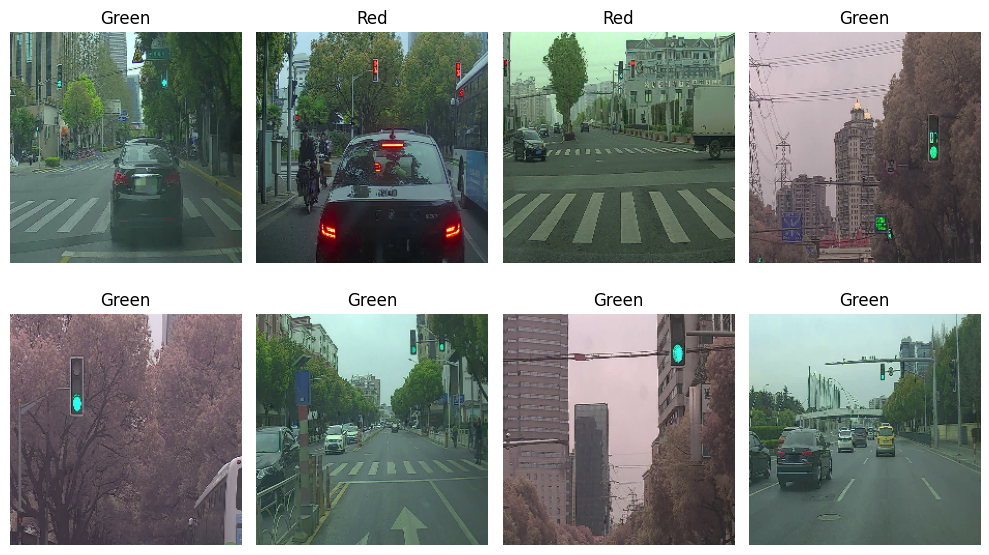

In [6]:
plt.figure(figsize=(10, 6))
for images, labels in train_ds.take(1):
    for i in range(min(8, len(images))):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        label_idx = int(labels[i].numpy()[0])
        plt.title(class_names[label_idx])
        plt.axis('off')
plt.tight_layout()
plt.savefig('figure_1_sample_training_images.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Helper Functions

In [8]:
def plot_history(history, title, filename_prefix):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{filename_prefix}_accuracy.png', dpi=200, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{filename_prefix}_loss.png', dpi=200, bbox_inches='tight')
    plt.show()


def evaluate_model(model, dataset, model_name, filename_prefix):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0).flatten()
        preds = (probs >= 0.5).astype(int)
        y_prob.extend(probs)
        y_pred.extend(preds)
        y_true.extend(labels.numpy().astype(int).flatten())

    print(f'Classification report for {model_name}:')
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.savefig(f'{filename_prefix}_confusion_matrix.png', dpi=200, bbox_inches='tight')
    plt.show()

    return y_true, y_pred, y_prob, cm


def show_five_test_predictions(model, dataset, filename='figure_five_test_predictions.png'):
    rows = []
    plt.figure(figsize=(14, 6))
    shown = 0

    for images, labels in dataset:
        probs = model.predict(images, verbose=0).flatten()
        for i in range(len(images)):
            if shown == 5:
                break

            prob_red = float(probs[i])
            pred_idx = 1 if prob_red >= 0.5 else 0
            actual_idx = int(labels[i].numpy()[0])

            rows.append({
                'Image Number': shown + 1,
                'Actual Label': class_names[actual_idx],
                'Predicted Label': class_names[pred_idx],
                'Probability of Red class': round(prob_red, 4)
            })

            ax = plt.subplot(1, 5, shown + 1)
            plt.imshow(images[i].numpy().astype('uint8'))
            plt.title(f"Actual: {class_names[actual_idx]} Pred: {class_names[pred_idx]} P(Red): {prob_red:.2f}")
            plt.axis('off')
            shown += 1

        if shown == 5:
            break

    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()

    pred_df = pd.DataFrame(rows)
    pred_df.to_csv('table_five_test_predictions.csv', index=False)
    return pred_df

## 6. Model 1 - Frozen VGG16 + Data Augmentation

Data augmentation is included from the first model to reduce memorisation and make the baseline more realistic. The VGG16 convolutional base is frozen, so only the classifier head is trained.

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name='data_augmentation')

base_model_1 = tf.keras.applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model_1.trainable = False

model_1 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Lambda(tf.keras.applications.vgg16.preprocess_input),
    base_model_1,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(1, activation='sigmoid')
])

model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.4811 - loss: 2.0821 - val_accuracy: 0.6333 - val_loss: 1.0226
Epoch 2/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4389 - loss: 1.5816 - val_accuracy: 0.6333 - val_loss: 0.9744
Epoch 3/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5492 - loss: 1.4133 - val_accuracy: 0.6000 - val_loss: 0.9232
Epoch 4/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5107 - loss: 1.2206 - val_accuracy: 0.7000 - val_loss: 0.8056
Epoch 5/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5272 - loss: 1.0770 - val_accuracy: 0.7333 - val_loss: 0.7303
Epoch 6/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6506 - loss: 0.9925 - val_accuracy: 0.6333 - val_loss: 0.8131
Epoch 7/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5619 - loss: 1.0664 - val_accuracy: 0.6333 - val_loss: 0.7737
Epoch 8/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6203 - loss: 0.9484 - val_accuracy: 0.7000 - val_loss: 0.6338
Epoch 9/

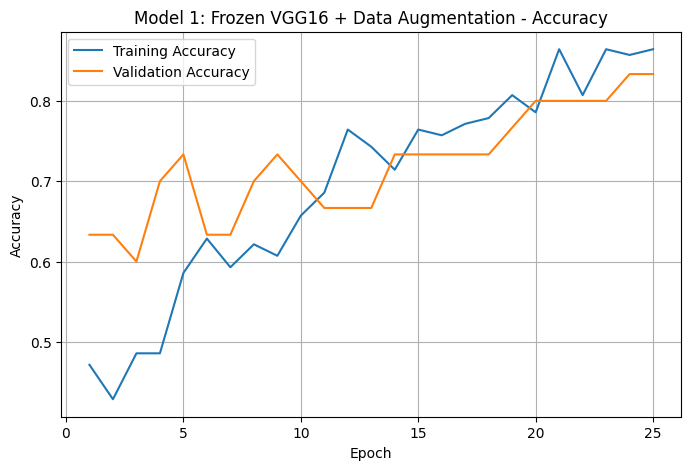

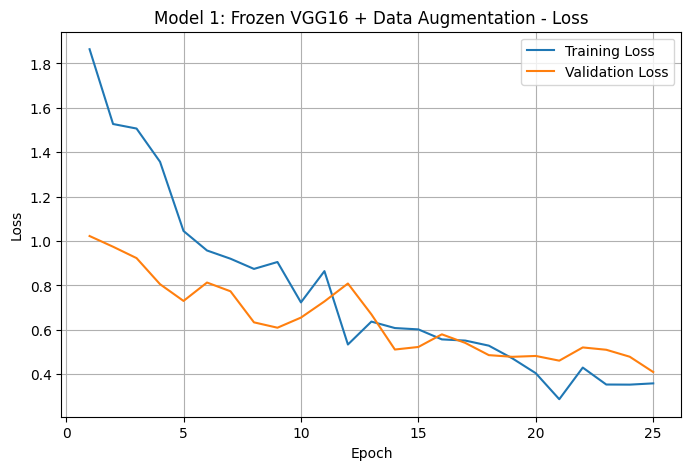

Classification report for Model 1 VGG16 Baseline:
              precision    recall  f1-score   support

       Green       0.93      0.87      0.90        15
         Red       0.88      0.93      0.90        15

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



2026-05-02 14:37:15.694749: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


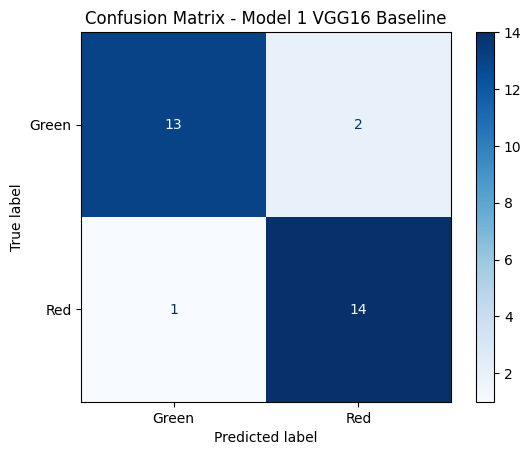

In [10]:
history_1 = model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

test_loss_1, test_acc_1 = model_1.evaluate(test_ds, verbose=0)
print(f'Model 1 VGG16 baseline test accuracy: {test_acc_1:.4f}')
print(f'Model 1 VGG16 baseline test loss: {test_loss_1:.4f}')

plot_history(history_1, 'Model 1: Frozen VGG16 + Data Augmentation', 'figure_2_model_1_vgg16_augmented')
y_true_1, y_pred_1, y_prob_1, cm_1 = evaluate_model(model_1, test_ds, 'Model 1 VGG16 Baseline', 'figure_3_model_1')

## 7. Model 2 - Improvement 1: Stronger Regularisation

This model keeps VGG16 frozen but uses stronger dropout and L2 regularisation. The aim is to reduce overfitting and improve validation stability.

In [11]:
base_model_2 = tf.keras.applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model_2.trainable = False

model_2 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Lambda(tf.keras.applications.vgg16.preprocess_input),
    base_model_2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.50),
    layers.Dense(1, activation='sigmoid')
])

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4646 - loss: 1.7018 - val_accuracy: 0.3333 - val_loss: 1.4642
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5050 - loss: 1.6305 - val_accuracy: 0.4000 - val_loss: 1.3004
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5642 - loss: 1.6913 - val_accuracy: 0.4333 - val_loss: 1.1895
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5735 - loss: 1.3013 - val_accuracy: 0.6000 - val_loss: 1.1091
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6237 - loss: 1.1777 - val_accuracy: 0.6333 - val_loss: 1.0622
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5812 - loss: 1.2411 - val_accuracy: 0.6667 - val_loss: 0.9980
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6113 - loss: 1.2325 - val_accuracy: 0.7000 - val_loss: 0.9361
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5713 - loss: 1.3615 - val_accuracy: 0.7333 - val_loss: 0.8343
Epoch 9/

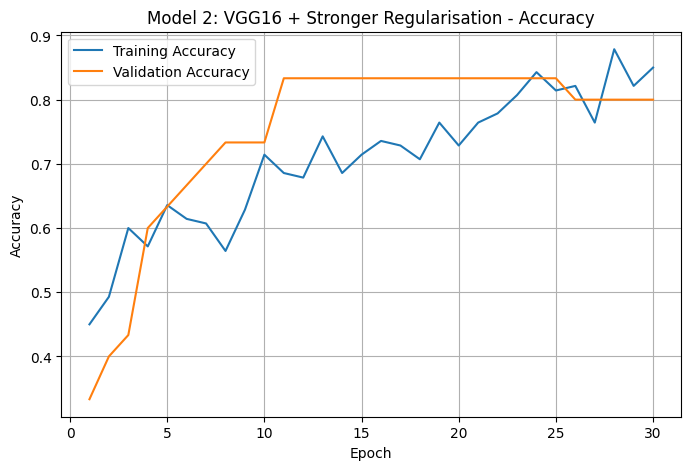

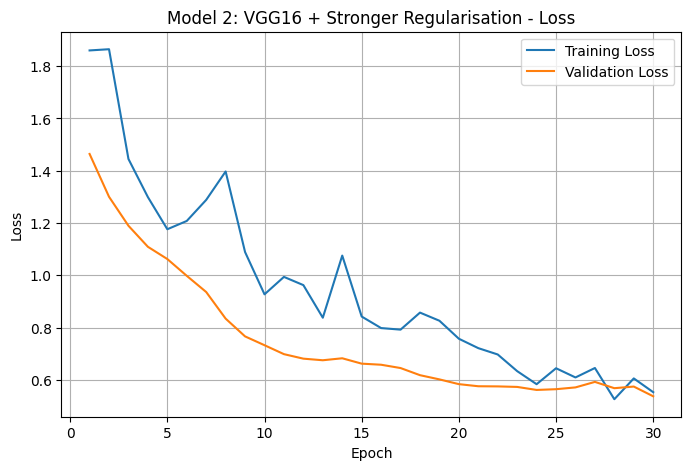

Classification report for Model 2 Regularised VGG16:
              precision    recall  f1-score   support

       Green       1.00      0.87      0.93        15
         Red       0.88      1.00      0.94        15

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



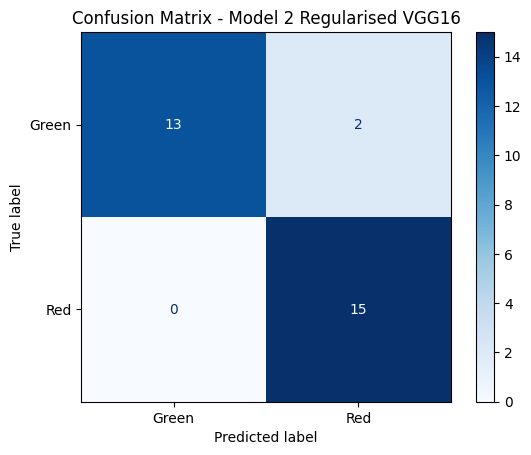

In [12]:
history_2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True
        )
    ]
)

test_loss_2, test_acc_2 = model_2.evaluate(test_ds, verbose=0)
print(f'Model 2 regularised VGG16 test accuracy: {test_acc_2:.4f}')
print(f'Model 2 regularised VGG16 test loss: {test_loss_2:.4f}')

plot_history(history_2, 'Model 2: VGG16 + Stronger Regularisation', 'figure_4_model_2_vgg16_regularised')
y_true_2, y_pred_2, y_prob_2, cm_2 = evaluate_model(model_2, test_ds, 'Model 2 Regularised VGG16', 'figure_5_model_2')

## 8. Model 3 - Improvement 2: Fine-tuning Block 5 of VGG16

Fine-tuning adapts the final convolutional block of VGG16 to the traffic-light dataset. Only `block5` is unfrozen and a very small learning rate is used to avoid destroying the pretrained features.

In [21]:
# Improvement Method 2: Stable Fine-tuning of VGG16

# Unfreeze the VGG16 base model
base_model_1.trainable = True

# First freeze every layer
for layer in base_model_1.layers:
    layer.trainable = False

# Then only unfreeze the final two convolutional layers
for layer in base_model_1.layers:
    if layer.name in ["block5_conv2", "block5_conv3"]:
        layer.trainable = True

# Check which layers are trainable
for layer in base_model_1.layers:
    print(layer.name, layer.trainable)

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-7),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 True
block5_conv3 True
block5_pool False


Epoch 1/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8728 - loss: 0.5063 - val_accuracy: 0.8333 - val_loss: 0.5186 - learning_rate: 5.0000e-07
Epoch 2/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8792 - loss: 0.4748 - val_accuracy: 0.8333 - val_loss: 0.5153 - learning_rate: 5.0000e-07
Epoch 3/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8692 - loss: 0.5282 - val_accuracy: 0.8333 - val_loss: 0.5142 - learning_rate: 5.0000e-07
Epoch 4/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8888 - loss: 0.5183 - val_accuracy: 0.8333 - val_loss: 0.5160 - learning_rate: 5.0000e-07
Epoch 5/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8481 - loss: 0.6245
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.999999974752428e-08.
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8483 - loss: 0.6197 - val_accuracy: 0.8333 - val_loss: 0.5191 - learning_rate: 5.0000e-07
Epoch 6/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8752 - loss: 0.5053 - val_accura

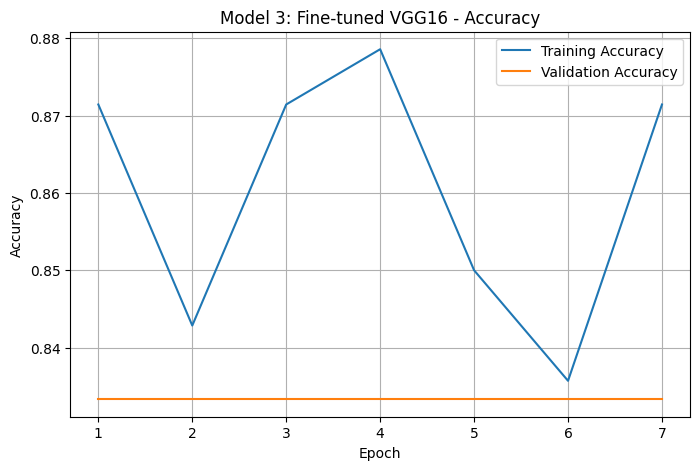

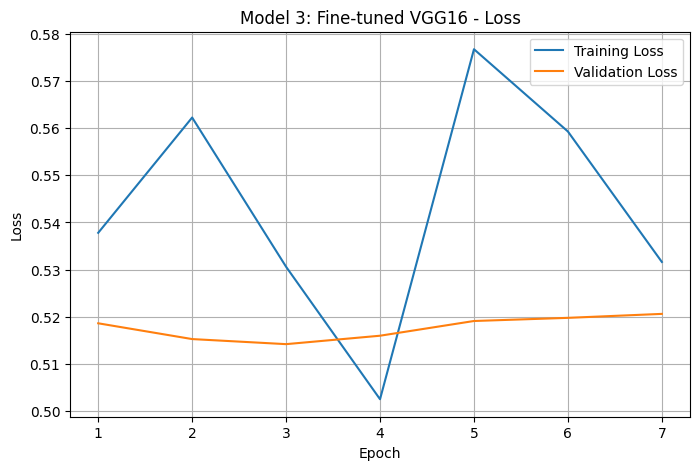

Classification report for Model 3 Fine-tuned VGG16:
              precision    recall  f1-score   support

       Green       1.00      0.87      0.93        15
         Red       0.88      1.00      0.94        15

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



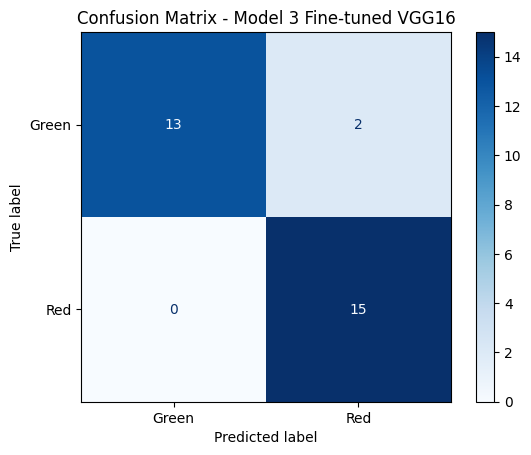

In [22]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-8,
        verbose=1
    )
]

history_3 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=fine_tune_callbacks
)

test_loss_3, test_acc_3 = model_2.evaluate(test_ds, verbose=0)

print(f"Stable fine-tuned VGG16 test accuracy: {test_acc_3:.4f}")
print(f"Stable fine-tuned VGG16 test loss: {test_loss_3:.4f}")

plot_history(history_3, 'Model 3: Fine-tuned VGG16', 'figure_6_model_3_vgg16_finetuned')
y_true_3, y_pred_3, y_prob_3, cm_3 = evaluate_model(model_2, test_ds, 'Model 3 Fine-tuned VGG16', 'figure_7_model_3')

## 9. Model Comparison

In [15]:
results = pd.DataFrame({
    'Model': [
        'Model 1: Frozen VGG16 + augmentation',
        'Model 2: VGG16 + stronger regularisation',
        'Model 3: Fine-tuned VGG16'
    ],
    'Test Accuracy': [test_acc_1, test_acc_2, test_acc_3],
    'Test Loss': [test_loss_1, test_loss_2, test_loss_3]
})

results.to_csv('table_model_comparison.csv', index=False)
results

,Model,Test Accuracy,Test Loss
0,Model 1: Frozen VGG16 + augmentation,0.900000,0.273929
1,Model 2: VGG16 + stronger regularisation,0.933333,0.416910
2,Model 3: Fine-tuned VGG16,0.933333,0.395184


## 10. Five Unseen Test Images

The five images below are selected from the test dataset only. They were not used during training.

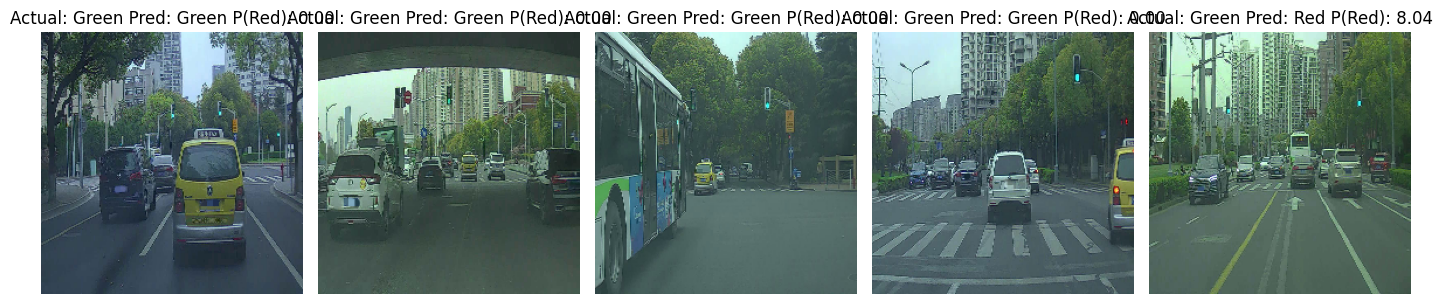

,Image Number,Actual Label,Predicted Label,Probability of Red class
0,1,Green,Green,0.0000
1,2,Green,Green,0.0000
2,3,Green,Green,0.0000
3,4,Green,Green,0.0000
4,5,Green,Red,8.0442


In [18]:
# Choose the best model manually after comparing the table above.
# Default: use the fine-tuned model. If Model 2 performs better, change best_model = model_2 is already the same object after fine-tuning.
best_model = base_model_1

five_predictions_df = show_five_test_predictions(
    best_model,
    test_ds,
    filename='figure_8_five_test_predictions.png'
)

five_predictions_df

## 11. Saving the Final Model

In [ ]:
best_model.save('best_vgg16_traffic_light_model.keras')
print('Saved best_vgg16_traffic_light_model.keras')

## 12. Notes for the Report

After running the notebook, insert the following into the report:

- The model comparison table from `table_model_comparison.csv`.
- Accuracy and loss plots for each model.
- The confusion matrix for the best model.
- The five test prediction table from `table_five_test_predictions.csv`.
- A short explanation of whether the improvement methods increased accuracy, reduced validation loss, or reduced overfitting.